In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import torch.utils.data as data
import torch_geometric
from torch_geometric.datasets import WebKB
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
import networkx as nx
from atten_layer import ATLayer

/home/siddy/anaconda3/envs/GDL/lib/python3.8/site-packages/torch/cuda/__init__.py:88: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
dataset = WebKB(root="/home/siddy/META/data", name='cornell')
data = dataset[0]

In [3]:
data

Data(x=[183, 1703], edge_index=[2, 298], y=[183], train_mask=[183, 10], val_mask=[183, 10], test_mask=[183, 10])

In [4]:
G = to_networkx(data, to_undirected=True)

In [5]:
def init_ball(radius: int, graph):
    edge_dict = {}
    for index, node in enumerate(graph.nodes()):
        paths = nx.single_source_shortest_path(graph, node, radius)
        if index not in edge_dict:
            edge_dict[index] = []
        for key, value in paths.items():
            if len(value) == 2:
                edge_dict[index].append(value)
            elif len(value)==3:
                edge_dict[index].append(value[1:])
    return edge_dict

In [6]:
edge_dict= init_ball(radius=2, graph=G)

In [7]:
class Edge_atten(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=1, concat_heads=True, alpha=0.2):
        super().__init__()
        self.num_heads=num_heads
        self.concat_heads = concat_heads
        if self.concat_heads:
            assert out_channels % num_heads==0, "number of output channels must be multiple of count of heads"
            out_channels = out_channels // num_heads

        self.linear = nn.Linear(in_channels, out_channels*num_heads)
        self.a = nn.Parameter(torch.Tensor(num_heads, 2*out_channels))
        self.leakyrelu = nn.LeakyReLU(alpha)

        #xavier uniform initialization
        nn.init.xavier_uniform_(self.linear.weight.data, gain=1.414)
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
    
    def forward(self, node_feats, edge_index):
        node_feats = torch.unsqueeze(node_feats, dim=0)
        batch_size, num_nodes = node_feats.size(0), node_feats.size(1)
        node_feats = self.linear(node_feats)
        node_feats = node_feats.view(batch_size, num_nodes, self.num_heads, -1)
        node_feats_flat = node_feats.view(batch_size*num_nodes, self.num_heads, -1)
        edge_indices_row = edge_index[0]
        edge_indices_col = edge_index[1]
        a_input = torch.cat([
            torch.index_select(input=node_feats_flat, index=edge_indices_row, dim=0),
            torch.index_select(input=node_feats_flat, index=edge_indices_col, dim=0)
        ], dim=-1)
        attn_logits = torch.einsum('bhc, hc->bh', a_input, self.a)
        attn_logits = self.leakyrelu(attn_logits)
        attn_probs = F.softmax(attn_logits, dim=-2)
        return attn_probs

In [8]:
edge_list = torch.permute(torch.tensor(edge_dict[0], dtype=torch.long), (1,0))

In [9]:
edge_list

tensor([[  0,   0, 101, 101, 101],
        [101, 122,   8,  20, 109]])

In [10]:
edge_atten = Edge_atten(in_channels=data.x.size(1), out_channels=64)

In [11]:
atten_probs = edge_atten(data.x, edge_list)
torch.squeeze(atten_probs).detach()

tensor([0.2548, 0.1638, 0.3988, 0.0909, 0.0916])

In [12]:
edge_list = list(tuple(i) for x,i in enumerate(edge_list.t().numpy()))

In [13]:
weights = torch.squeeze(atten_probs).detach().numpy()

In [14]:
weighted_edge_list = []
for index,edges in enumerate(edge_list):
    # for k in weights:
    #     weighted_edge_list.append((i,j)+(k))
    weighted_edge_list.append(edges+(weights[index],))
print(weighted_edge_list)

[(0, 101, 0.25480014), (0, 122, 0.16377659), (101, 8, 0.39884725), (101, 20, 0.09094483), (101, 109, 0.091631256)]


In [15]:
g_ball = nx.Graph()
g_ball.add_weighted_edges_from(weighted_edge_list)

In [16]:
import networkx as nx
import numpy as np
import math

# matplotlib setting
%matplotlib inline
import matplotlib.pyplot as plt

# to print logs in jupyter notebook
import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.ERROR)

# load GraphRicciCuravture package
from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci


# load python-louvain for modularity computation
import community.community_louvain as community_louvain

# for ARI computation
from sklearn import preprocessing, metrics

In [21]:
orc = OllivierRicci(g_ball, alpha=0.5, verbose="TRACE")


In [23]:
orc.compute_ricci_curvature()
G_orc = orc.G.copy() 

TRACE:Number of nodes: 6
TRACE:Number of edges: 5
TRACE:Start to compute all pair shortest path.
TRACE:0.000646 secs for all pair by NetworKit.
INFO:0.107157 secs for Ricci curvature computation.


In [26]:
G_orc

Ball graph of center node 0
Ricci curvature of edge (0,101) is -0.065405
Ricci curvature of edge (0,122) is 0.373226
Ricci curvature of edge (101,8) is 0.473537
Ricci curvature of edge (101,20) is -0.344520
Ricci curvature of edge (101,109) is -0.336258


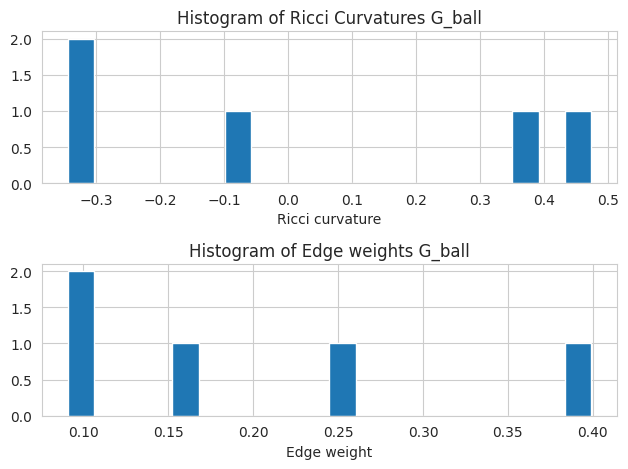

In [25]:
def show_results(G, curvature="ricciCurvature"):

    # Print the first five results
    print("Ball graph of center node 0")
    for n1,n2 in list(G.edges())[:5]:
        print("Ricci curvature of edge (%s,%s) is %f" % (n1 ,n2, G[n1][n2][curvature]))

    # Plot the histogram of Ricci curvatures
    plt.subplot(2, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=20)
    plt.xlabel('Ricci curvature')
    plt.title("Histogram of Ricci Curvatures G_ball")

    # Plot the histogram of edge weights
    plt.subplot(2, 1, 2)
    weights = nx.get_edge_attributes(G, "weight").values()
    plt.hist(weights,bins=20)
    plt.xlabel('Edge weight')
    plt.title("Histogram of Edge weights G_ball")

    plt.tight_layout()

show_results(G_orc)